In [2]:
# declare libraries
import json
import os
import pathlib
import time
import geopandas as gpd
import pandas as pd
import numpy as np
import shapely

from zipfile import ZipFile
import rioxarray as rxr
import xarray as xr
import rasterio
from rasterio.plot import show


import matplotlib.pyplot as plt

import requests
from requests.auth import HTTPBasicAuth
from planet import Session, DataClient, OrdersClient, Auth, Planet

import os
import sys

sys.path.append("../utils")

import config
# import planet_api

import pyproj

# Point this to where your actual proj.db is (inside your conda env)
# pyproj.datadir.set_data_dir("/Users/rachelfswick/.conda/envs/wildfire_prep/share/proj") 

from pyproj import CRS

# declare misc vars
crs = "EPSG:4326"
#crs = "EPSG:3310"
county_filepath = "/capstone/wildfire_prep/data/ca_counties/CA_Counties.shp"
# sb_bbox = [-125, 34.25, -119.0, 38.0]

data_api_url = "https://api.planet.com/data/v1"
orders_api_url = 'https://api.planet.com/compute/ops/orders/v2' 

# load CA county shps
counties = (
   gpd
   .read_file(county_filepath)
   .to_crs(crs)
  )

# isolate sb shp
sb_county = (
    counties
    .loc[counties["NAME"] == "Santa Barbara"]
    .explode(ignore_index=True)
    .iloc[[0]]
    )

planet_api = config.planet_api

Set api key and authorize

In [ ]:
planet_key = config.planet_api

# authentication
auth = HTTPBasicAuth(planet_key, "")

# check we are communicating with http properly
response = requests.get(data_api_url, auth=auth)
print(response)

# make function for pagenation
def p(data):
    print(json.dumps(data, indent = 2))

<Response [200]>


init session

this is important for something, I forget what

In [3]:
# setup
session = requests.Session()

# authenticate
session.auth = (planet_key, "")

res = session.get(data_api_url)

test polygon

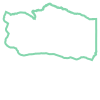

In [4]:
sb_county.boundary.iloc[0]

simplify polygon

In [5]:
sb_simple = (
    sb_county 
    #.to_crs("EPSG:3310")
    .simplify(0.02) # reduce number of verticies
    .to_frame(name="geometry") # convert back to gdf
    # .pipe(gpd.GeoDataFrame)
    )

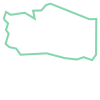

In [6]:
sb_simple.boundary.iloc[0]

get geojson

In [7]:
sb_json = (
        sb_county
        .simplify(0.02) # reduce number of verticies
        .to_frame(name="geometry") # convert back to gdf
        .to_geo_dict() # convert polygon to geojson format
        ["features"][0] # select first and only feature
        ["geometry"] # select geometry attribute
    )

#sb_json["coordinates"] = [[*sb_json["coordinates"][0]]]

len(sb_json["coordinates"][0])

25

set filters

In [8]:
# define filter for all scenes touching sb county
geometry_filter = {
    "type": "GeometryFilter", # set filter type as geometry
    "field_name": "geometry", # give json column containing geometry
    "config": sb_json # input sb county json
}


# # set date filter
# date_range_filter = {
#     "type": "DateRangeFilter", 
#     "field_name": "acquired",  
#     "config": { 
#         "gte": "2018-01-01T00:00:00.000Z",
#         "lt":  "2024-01-01T00:00:00.000Z"
#     }
# }

# DEMO DATE RANGE FILTER
# ONLY FOR ONE MONTH
date_range_filter = {
    "type": "DateRangeFilter", 
    "field_name": "acquired",  # selects for when imagery was measured, not published
    "config": { 
        "gte": "2022-05-01T00:00:00.000Z", # greater then equal to
        "lt":  "2022-06-01T00:00:00.000Z" # less then
    }
}

# # set cloud cover filter
# cloud_cover_filter = {
#     "type": "RangeFilter", 
#     "field_name": "cloud_cover", 
#     "config": {
#         "lt": 0.5
#     }
# }

# MAKING CLOUD FILTER STRICTER TO MAKE NUM SCENES UNDER 500
cloud_cover_filter = {
    "type": "RangeFilter", # generalized filter type that takes range of values
    "field_name": "cloud_cover", # ask for cloud cover
    "config": {
        "lt": 0.01 # filter for all scenes w <1% cloud cover
    }
}

# combine filters
combined_filters = {
    "type": "AndFilter", # filter type for and conditional
    "config": [geometry_filter, date_range_filter, cloud_cover_filter]
}

Run quick search based on filters

In [9]:
# defines package type
# PSScene has orthorectified 8 and 4 band imagery with the udm2 file
# you can take imagery from multiple types but we only need this one
item_types = ["PSScene"]

# feed our filters and package type selection into a filter dict
search_request = {
    "item_types": item_types,
    "filter": combined_filters
}

# and we search Planet labs imagery with it
search_result = \
    requests.post( # post sends our request to https api
        "https://api.planet.com/data/v1/quick-search",
        auth = HTTPBasicAuth(planet_key, ''),  # we give it our key
        json = search_request # and our request dict
    )

print(search_result)

<Response [200]>


Print first 10 scene ids

In [10]:
first_ids = [feature['id'] for feature in search_result.json()["features"]]
print(f"First 10 ids: {first_ids[0:10]}")

First 10 ids: ['20220504_175307_95_2442', '20220531_183405_05_240a', '20220528_181832_96_2484', '20220524_181010_18_2231', '20220524_181012_39_2231', '20220524_181016_82_2231', '20220524_181014_61_2231', '20220524_181007_97_2231', '20220520_181311_81_2231', '20220520_181309_60_2231']


grab first 10 ids

In [11]:
id = first_ids[0:10]

# for id in id[0:3]
print(f"First 3 IDs...")
for i in id[0:3]: 
    print(f"\t{i}")

print(f"Total number of IDs...\n\t{ len(id) }")

First 3 IDs...
	20220504_175307_95_2442
	20220531_183405_05_240a
	20220528_181832_96_2484
Total number of IDs...
	10


### Requests example

In this notebook, we will be using `requests` to communicate with the orders v2 API. First, we will check our orders list to make sure authentication and communication is working as expected.

We want to get a response code of `200` from this API call. To troubleshoot other response codes, see the [List Orders](https://developers.planet.com/apis/orders/reference/#tag/Orders/operation/listOrders) API reference.

In [12]:
# init auth with key again
auth = HTTPBasicAuth(planet_key, "")

# test that we are communicating with api successfully
order_response = requests.get(orders_api_url, auth=auth)
print(order_response)

<Response [200]>


Make order request

In [13]:
# set content type to json
headers = {"content-type": "application/json"}

# # init order parameters
# product = [
#     { 
#         "item_ids": id, 
#         "item_type": "PSScene", 
#         "product_bundle": "analytic_8b_sr_udm2", # ortho 8 band surface reflectance with udm2
#     }
# ]

# init order parameters, this one has the 4 band
product = [
    { 
        "item_ids": id, 
        "item_type": "PSScene", 
        "product_bundle": "ortho_analytic_4b_sr", # ortho 4 band surface reflectance
    }
]

order_request = {
    "name": "wildfire_250_scene_test1", 
    "products": product, 
    "delivery": {
        "single_archive": True, # archive all bundles together in single file
        "archive_type": "zip" # get zip folder
        }
}

create tool jsons

In [14]:
# init clip to sb county
clip =  {
    "clip": {
        "aoi": sb_json
    }
}

# init ndvi calculation
bandmath = {
    "bandmath": {
        "b1": "b1",
        "b2": "b2", 
        "b3": "b3", 
        "b4": "b4", 
        "b5": "(b4 - b3) / (b4 + b3)"
    }
}

# create request json
tool_request = { 
    "name": "tool_test", 
    "products": product, 
    "tools": [clip, bandmath], 
    "delivery": {"single_archive": True, "archive_type": "zip"}
}

In [15]:
def place_order(request, auth):

    # make order request
    response = requests.post(
        orders_api_url, 
        data = json.dumps(request), 
        auth = auth, 
        headers = headers
        )
    print(response.json())

    # get ids of scenes
    order_id = response.json()["id"]
    print(order_id)

    # construct the url of our order
    order_url = orders_api_url + '/' + order_id
    
    return order_url

In [16]:
tool_request

{'name': 'tool_test',
 'products': [{'item_ids': ['20220504_175307_95_2442',
    '20220531_183405_05_240a',
    '20220528_181832_96_2484',
    '20220524_181010_18_2231',
    '20220524_181012_39_2231',
    '20220524_181016_82_2231',
    '20220524_181014_61_2231',
    '20220524_181007_97_2231',
    '20220520_181311_81_2231',
    '20220520_181309_60_2231'],
   'item_type': 'PSScene',
   'product_bundle': 'ortho_analytic_4b_sr'}],
 'tools': [{'clip': {'aoi': {'type': 'Polygon',
     'coordinates': (((-120.73430466331337, 34.900693798243516),
       (-120.70280766781855, 34.999979809821376),
       (-120.6341566531082, 34.95956680999822),
       (-120.44026262569045, 34.9883278241522),
       (-120.30183959581318, 34.9055758254958),
       (-120.32383560911286, 35.01731883498905),
       (-120.20991959126518, 35.02058684190875),
       (-120.14318258728626, 35.095743853571214),
       (-120.08209658023088, 35.11468285869654),
       (-119.53576947195349, 34.89758087046367),
       (-119.442

In [17]:
# safety check, only run cell if you specifically say "yes"
response = input("Are you sure you want to execute this cell? (yes/no): ")
if response.lower() == "yes":



    # clip tool works!!
    clip_url = place_order(clip_request, auth)



    print("Cell executed!")
else:
    print("Execution canceled.")


Execution canceled.


In [18]:
# make most recent order link a global variable
# nvm this didn't work
# globals()["most_recent_planet_order"] = clip_url

### Poll for order success

In [19]:
def poll_for_success(order_url, auth, num_loops = 60): 
    i = 0
    while(i < num_loops): 

        # iterate
        i += 1

        # get order request
        r = requests.get(order_url, auth = auth)
        response = r.json()

        # grab current state
        state = response["orders"][0]["state"]
        print(state)

        # compare it to a variety of end states and print it
        end_states = ["success", "failed", "partial"]
        if state in end_states:
            print(f"End State: {state}")
            break

        # wait 30 secs
        time.sleep(30)



In [20]:
# most_recent_planet_order

In [21]:
poll_for_success(orders_api_url, auth)

success
End State: success


### download

In [22]:
# ping planet
r = requests.get(orders_api_url, auth = auth)

# turn response into a json/dict
response = r.json()

# isolate state of most recent order
order_results = response["orders"][0]["state"]
order_results

'success'

In [23]:
response

{'_links': {'_self': 'https://api.planet.com/compute/ops/orders/v2'},
 'orders': [{'_links': {'_self': 'https://api.planet.com/compute/ops/orders/v2/caab69ae-2d4f-4ee9-9f15-f4b460fe861f'},
   'created_on': '2025-04-14T21:28:35.236029Z',
   'delivery': {'archive_filename': 'output.zip',
    'archive_type': 'zip',
    'single_archive': True},
   'error_hints': [],
   'id': 'caab69ae-2d4f-4ee9-9f15-f4b460fe861f',
   'last_message': 'Manifest delivery completed',
   'last_modified': '2025-04-14T21:46:36.576978Z',
   'name': 'wildfire santa barbara',
   'products': [{'item_ids': ['20220504_175307_95_2442',
      '20220531_183405_05_240a',
      '20220528_181832_96_2484',
      '20220524_181010_18_2231',
      '20220524_181012_39_2231',
      '20220524_181016_82_2231',
      '20220524_181014_61_2231',
      '20220524_181007_97_2231',
      '20220520_181311_81_2231',
      '20220520_181309_60_2231'],
     'item_type': 'PSScene',
     'product_bundle': 'analytic_8b_sr_udm2'}],
   'state': 'suc

In [24]:
response["orders"][0]["id"]

'caab69ae-2d4f-4ee9-9f15-f4b460fe861f'

In [25]:
# safety check, only run cell if you specifically say "yes"
response = input("Are you sure you want to execute this cell? (yes/no): ")
if response.lower() == "yes":


    Planet().orders.download_order(
        response["orders"][0]["id"], # get order id
        overwrite = False, # don't overwrite files that already exist
        directory = "/data/wildfire_prep" # set directory to our data folder in workbench-2
        )



    print("Cell executed!")
else:
    print("Execution canceled.")

Execution canceled.


In [26]:
path = "/data/wildfire_prep/caab69ae-2d4f-4ee9-9f15-f4b460fe861f"

In [27]:
# safety check, only run cell if you specifically say "yes"
response = input("Are you sure you want to execute this cell? (yes/no): ")
if response.lower() == "yes":

    with ZipFile(f"{path}/output.zip", 'r') as zip: 

        zip.printdir()

        # extracting all the files 
        print('Extracting all the files now...') 
        zip.extractall(path=path) 
        print('Done!') 



    print("Cell executed!")
else:
    print("Execution canceled.")

Execution canceled.


In [28]:
test_rast_path = f"{path}/files/20220504_175307_95_2442_3B_AnalyticMS_SR_8b_clip.tif"
# test_rast_path
test_rast = rxr.open_rasterio(test_rast_path)
# test_rast.squeeze().plot.imshow(robust = True)

In [29]:
tif_list = []
for file in os.listdir(path=f"{path}/files"):
    if "SR_8b_clip.tif" in file:
        tif_list.append(file)

tif_list2 = []
for file in os.listdir(path=f"{path}/files"):
    if "SR_8b_clip.tif" in file:
        tif_list2.append(f"{path}/files/{file}")

In [30]:
tif_list2

['/data/wildfire_prep/caab69ae-2d4f-4ee9-9f15-f4b460fe861f/files/20220528_181832_96_2484_3B_AnalyticMS_SR_8b_clip.tif',
 '/data/wildfire_prep/caab69ae-2d4f-4ee9-9f15-f4b460fe861f/files/20220531_183405_05_240a_3B_AnalyticMS_SR_8b_clip.tif',
 '/data/wildfire_prep/caab69ae-2d4f-4ee9-9f15-f4b460fe861f/files/20220504_175307_95_2442_3B_AnalyticMS_SR_8b_clip.tif',
 '/data/wildfire_prep/caab69ae-2d4f-4ee9-9f15-f4b460fe861f/files/20220524_181016_82_2231_3B_AnalyticMS_SR_8b_clip.tif',
 '/data/wildfire_prep/caab69ae-2d4f-4ee9-9f15-f4b460fe861f/files/20220520_181311_81_2231_3B_AnalyticMS_SR_8b_clip.tif',
 '/data/wildfire_prep/caab69ae-2d4f-4ee9-9f15-f4b460fe861f/files/20220524_181010_18_2231_3B_AnalyticMS_SR_8b_clip.tif',
 '/data/wildfire_prep/caab69ae-2d4f-4ee9-9f15-f4b460fe861f/files/20220524_181014_61_2231_3B_AnalyticMS_SR_8b_clip.tif',
 '/data/wildfire_prep/caab69ae-2d4f-4ee9-9f15-f4b460fe861f/files/20220524_181007_97_2231_3B_AnalyticMS_SR_8b_clip.tif',
 '/data/wildfire_prep/caab69ae-2d4f-4ee9

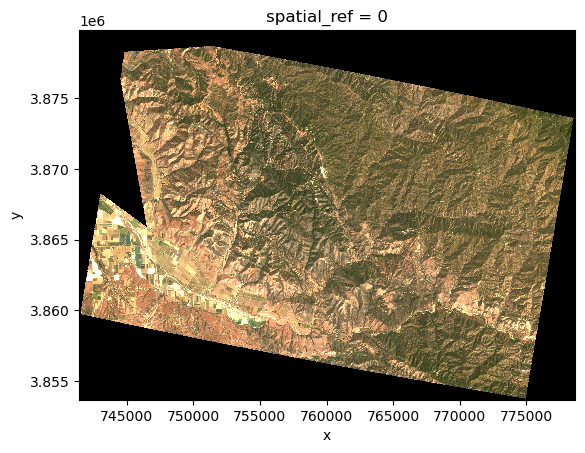

In [31]:
for tif_name in tif_list2:
    test_rast = rxr.open_rasterio(tif_name)

    r = test_rast.sel(band = 6)
    g = test_rast.sel(band = 4)
    b = test_rast.sel(band = 2)

    # Normalize the bands to [0, 1] for visualization
    # red_norm = (r - r.min()) / (r.max() - r.min())
    # green_norm = (g - g.min()) / (g.max() - g.min())
    # blue_norm = (b - b.min()) / (b.max() - b.min())

    # Stack the bands into an RGB image
    # rgb_image = np.dstack((r, g, b))
    rgb_image = xr.concat([r, g, b], dim="band").transpose("y", "x", "band")


    rgb_image.plot.imshow(robust=True)

    # plt.figure(figsize=(10, 8))
    # plt.imshow(rgb_image)
    # plt.title("RGB GeoTIFF Visualization")
    # plt.axis("off")  # Turn off the axes for better visualization
    # plt.show()


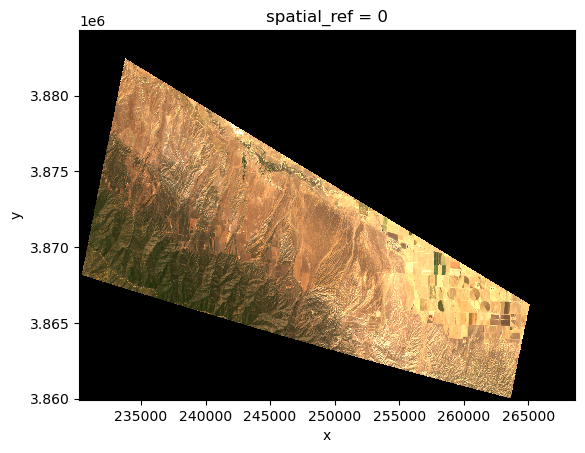

In [32]:
test_rast = rxr.open_rasterio(tif_list2[1])

r = test_rast.sel(band = 6)
g = test_rast.sel(band = 4)
b = test_rast.sel(band = 2)

# Normalize the bands to [0, 1] for visualization
# red_norm = (r - r.min()) / (r.max() - r.min())
# green_norm = (g - g.min()) / (g.max() - g.min())
# blue_norm = (b - b.min()) / (b.max() - b.min())

# Stack the bands into an RGB image
# rgb_image = np.dstack((r, g, b))
rgb_image = xr.concat([r, g, b], dim="band").transpose("y", "x", "band")


rgb_image.plot.imshow(robust=True)

# plt.figure(figsize=(10, 8))
# plt.imshow(rgb_image)
# plt.title("RGB GeoTIFF Visualization")
# plt.axis("off")  # Turn off the axes for better visualization
# plt.show()


In [33]:
rgb_image

<xarray.DataArray (y: 8128, x: 12814, band: 3)> Size: 625MB
array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
...
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint16)
Coordinates:
  * band         (band) int64 24B 6 4 2
  * x            (x) float64 103kB 2.302e+05 2.302e+05 ... 2.686e+05 2.686e+05
  * y            (y) float64 65kB 3.884e+06 3.884e+06 ... 3.86e+06 3.86e+06
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_IMAGEDESCRIPTION:  {"atmospheric_correction": {"aerosol_model": "...
    TIFFTAG_DATETIME:          2022:05:31 18:34:05
    AREA_OR_POINT:             Area
    _FillValue:                0
    scale_factor:              1.0
    add_offset:                0.0
    long_name:                 ('coastal_blue', 'blue', 'green_i', 'green', '...

In [34]:
rgb_image_df = rgb_image.to_dataframe(name="xtra_col")

In [35]:
rgb_image_coords = pd.DataFrame(
    {
        "x": rgb_image_df.index.get_level_values(1), 
        "y": rgb_image_df.index.get_level_values(0)
    }
)

x_max, x_min = rgb_image_coords.x.max(), rgb_image_coords.x.min()
y_min, y_max = rgb_image_coords.y.max(), rgb_image_coords.y.min()

print(f"x min: {x_min}")
print(f"y min: {y_min}")
print(f"x max: {x_max}")
print(f"y max: {y_max}")

x min: 230200.5
y min: 3884320.5
x max: 268639.5
y max: 3859939.5


In [36]:
tif_list = []
for file in os.listdir(path=f"{path}/files"):
    if "SR_8b_clip.tif" in file:
        tif_list.append(f"{path}/files/{file}")

tif_list

['/data/wildfire_prep/caab69ae-2d4f-4ee9-9f15-f4b460fe861f/files/20220528_181832_96_2484_3B_AnalyticMS_SR_8b_clip.tif',
 '/data/wildfire_prep/caab69ae-2d4f-4ee9-9f15-f4b460fe861f/files/20220531_183405_05_240a_3B_AnalyticMS_SR_8b_clip.tif',
 '/data/wildfire_prep/caab69ae-2d4f-4ee9-9f15-f4b460fe861f/files/20220504_175307_95_2442_3B_AnalyticMS_SR_8b_clip.tif',
 '/data/wildfire_prep/caab69ae-2d4f-4ee9-9f15-f4b460fe861f/files/20220524_181016_82_2231_3B_AnalyticMS_SR_8b_clip.tif',
 '/data/wildfire_prep/caab69ae-2d4f-4ee9-9f15-f4b460fe861f/files/20220520_181311_81_2231_3B_AnalyticMS_SR_8b_clip.tif',
 '/data/wildfire_prep/caab69ae-2d4f-4ee9-9f15-f4b460fe861f/files/20220524_181010_18_2231_3B_AnalyticMS_SR_8b_clip.tif',
 '/data/wildfire_prep/caab69ae-2d4f-4ee9-9f15-f4b460fe861f/files/20220524_181014_61_2231_3B_AnalyticMS_SR_8b_clip.tif',
 '/data/wildfire_prep/caab69ae-2d4f-4ee9-9f15-f4b460fe861f/files/20220524_181007_97_2231_3B_AnalyticMS_SR_8b_clip.tif',
 '/data/wildfire_prep/caab69ae-2d4f-4ee9

In [ ]:
# show(rasterio.open(f"{path}/files/{tif_list[4]}").read([5,3,1]))